# Google Reviews Word Cloud Analysis

Analyze positive and negative reviews using word clouds.

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('data/google_reviews_en.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   userName       500 non-null    str  
 1   at             500 non-null    str  
 2   content        500 non-null    str  
 3   score          500 non-null    int64
 4   thumbsUpCount  500 non-null    int64
dtypes: int64(2), str(3)
memory usage: 19.7 KB


## Data Preparation

In [2]:
df_hi = df[df['score']>=4]
df_lo = df[df['score']<4]

list_reviews_lo = df_lo['content'].astype(str).str.lower()
list_reviews_hi = df_hi['content'].astype(str).str.lower()

reviews_lo = ' '.join(list_reviews_lo)
reviews_hi = ' '.join(list_reviews_hi)

## Word Cloud: Negative Reviews (< 4 stars)

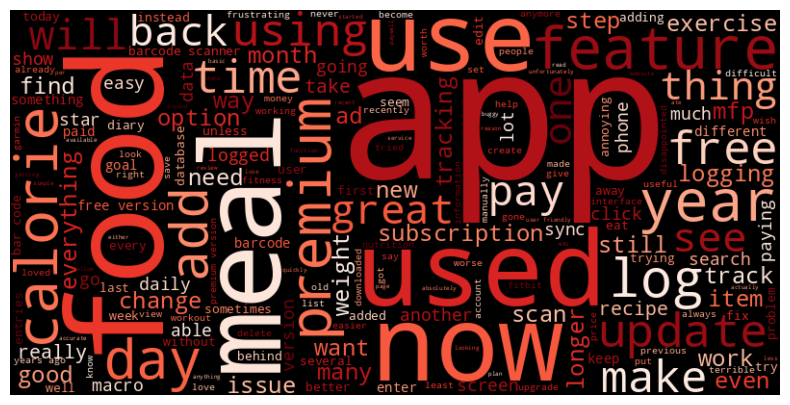

In [3]:
wordcloud_lo = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(reviews_lo)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_lo, interpolation='bilinear')
plt.axis('off')
plt.show()
wordcloud_lo.to_file('outputs/wordcloud_lo_en.png')

There is high frequency of words like:
- ads
- feature
- update

## Word Cloud: Positive Reviews (4+ stars)

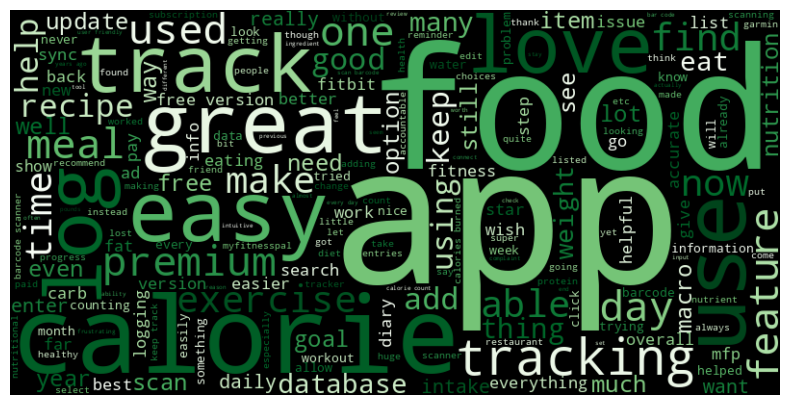

In [4]:
wordcloud_hi = WordCloud(
    width=800, height=400, background_color='black', colormap='Greens'
    ).generate(reviews_hi)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_hi, interpolation='bilinear')
plt.axis('off')
plt.show()
wordcloud_hi.to_file('outputs/wordcloud_hi_en.png')

High Frequency:
- calorie
- tracking
- food
- meal
- exercise
- easy

## Top Relevant Negative Reviews

In [5]:
import textwrap

df_lo = df_lo.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_negative_reviews = df_lo['content'].head(10).tolist()

def show_reviews(reviews:list):
    for i in range(len(reviews)):
        wrapped = textwrap.fill(f'review {i+1}: {reviews[i]}', width=100)
        print(wrapped)
        print()

show_reviews(most_relevant_negative_reviews)

review 1: I used the app for years and the barcode functions made it easier to use, especially when
you can't find the food items in just a search. It's too much of a hassle to continuously search for
items that are hit or miss could be easier to scan in a second, but to pay for a function all of a
sudden seems ridiculous. And the premium prices is too high.

review 2: Like a lot of other people, I've been using this app for years and it has helped me lose
and maintain my weight and fitness. With the newest change making the barcode scanner a premium
feature I will be uninstalling the app. The premium features just aren't worth the $80/year price
tag. Everything is becoming subscription based and I'm tired of it. For those looking for a free
alternative, Fitbit app allows barcode scanning for free (at least for now).

review 3: While I have been using the app since 2013, the latest update has ruined the functionality
of the app. Previously, I could type a brand name into the search and

### Notes:
- Replace with app-specific findings after reviewing the printed negative reviews.

## Top Relevant Positive Reviews

In [6]:
df_hi = df_hi.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_positive_reviews = df_hi['content'].head(10).tolist()

show_reviews(most_relevant_positive_reviews)

review 1: I only have the free version. And does everything needed. My only goal is to simply track
my calories to ensure I stay on track for the day. I don't get into counting macros/ tracking carbs
or anything that complicated. So I'm not too sure how those features work. But if you are a beginner
or just looking to be more mindful about calorie consumption. Works perfectly Also, syncs great to
Google Fit, so that's cool as well. 🙂

review 2: Just writing a review so it stops asking me. it's actually a good app. I haven't had any
pesky ads, the pop-up only appears if you click something that requires $$. Searching for food is
very easy, and it tells you if it's a certified food they logged. You can adjust portions to all
sorts of measurements. It saves all your logs, so you can easily scroll though and just quick add
your most common foods. So far, not disappointed and have been able to look at my eating habits
differently

review 3: I've been using this for maybe 3-4 years now. I've

### Notes:
- Replace with app-specific findings after reviewing the printed positive reviews.


# Arabic Reviews Word Cloud Analysis

In [7]:
import arabic_reshaper
from bidi.algorithm import get_display

df_arabic = pd.read_csv('data/google_reviews_ar.csv')
df_arabic['content_reshaped'] = df_arabic['content'].apply(
    lambda x: arabic_reshaper.reshape(str(x))
)

df_ar_lo = df_arabic[df_arabic['score']<4]
df_ar_hi = df_arabic[df_arabic['score']>=4]

## Arabic Word Cloud: Negative Reviews (< 4 stars)

In [8]:
def process_arabic(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return reshaped

list_reviews_lo_ar = df_ar_lo['content'].apply(process_arabic)
list_reviews_hi_ar = df_ar_hi['content'].apply(process_arabic)

reviews_lo_ar = ' '.join(list_reviews_lo_ar)
reviews_hi_ar = ' '.join(list_reviews_hi_ar)

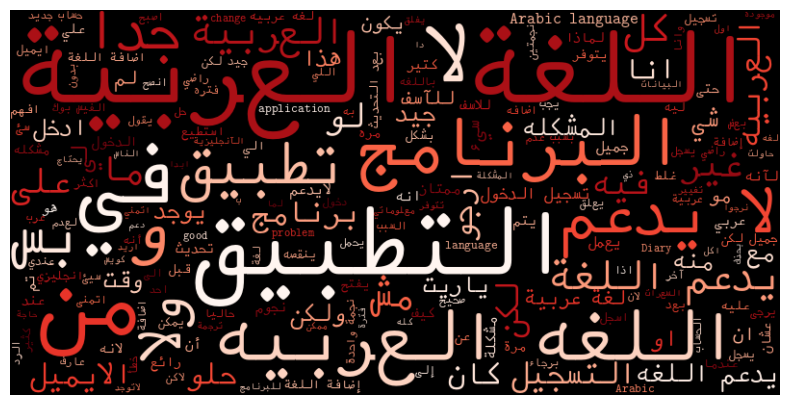

In [9]:
wordcloud_lo_ar = WordCloud(
    font_path='/usr/share/fonts/almfixed/almfixed.otf',
    width=800, 
    height=400, 
    background_color='black', 
    colormap='Reds',
).generate(reviews_lo_ar)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_lo_ar, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_lo_ar.to_file('outputs/wordcloud_lo_ar.png')

High Frequency:
- اللغة العربية
- التطبيق
- تسجيل الدخول
- لا يعمل
- مشكلة
- دعم

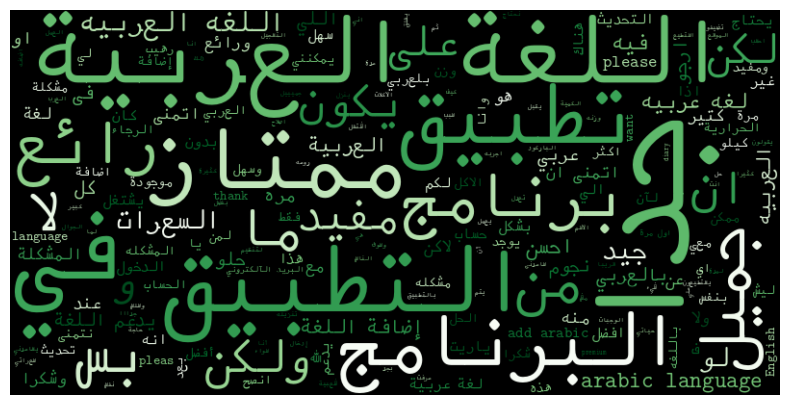

In [10]:
wordcloud_hi_ar = WordCloud(
    font_path='/usr/share/fonts/almfixed/almfixed.otf',
    width=800, 
    height=400, 
    background_color='black', 
    colormap='Greens',
).generate(reviews_hi_ar)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_hi_ar, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_hi_ar.to_file('outputs/wordcloud_hi_ar.png')

## Top Relevant Positive Arabic Reviews

In [11]:
df_ar_hi = df_ar_hi.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_positive_reviews_ar = df_ar_hi['content'].head(10).tolist()

show_reviews(most_relevant_positive_reviews_ar)

review 1: لا يوجد في هذا البرنامج اللغة العربية كيف علينا ان نتعامل مع هذا البرنامج ونحن لا نعلم
اللغة الأنكليزية

review 2: جميل جدا ولكن اتمنى ان يتوفر باللغه العربيه في أقرب وقت

review 3: برنامج اكثر من رائع بسيط وسهل ويمكن ربطة بسهولة بتطبيق Samsung Health وتسجيل القراءات من
الساعة الذكية يتميز التطبيق بانه يدعم اللغة العربية في إدخال الوجبات وسوف تجد جميع الاكلات الشعبية
فقط سجل الكمية وتابع الماكرو .. استخدمت التطبيق المجاني لمدة شهر وسوف اشترك في المدفوع لمدة سنة
برنامج نزلت بفضل الله اولا ثم متابعة التطبيق ٤ كيلو ..التطبيق يستاهل وزنه ذهب شكرا لكم

review 4: لماذا لا يدعم الغه العربيه هاذه أهم شيئ في البرنامج

review 5: نرجو اضافة اللغة العربية للبرنامج

review 6: كيف يمكنني تحويل البرنامج للغة العربية؟ لا يمكنني تحويل البرنامج الى اللغة العربية ارجوا
المساعدة

review 7: ممتاز جدا يخدم العربي و الانجليزي. لكن اول مرة تدخل الوزن يحسب لك بالفاصلة بعدها لازم تدخل
رقم صحيح يا ليت تعدلوا هالنقطة

review 8: التطبيق رائع ولكن أرجو إضافة اللغة العربية

review 9: أفضل تطبيق للسعرات الح

## Top Relevant Negative Arabic Reviews

In [12]:
df_ar_lo = df_ar_lo.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_negative_reviews_ar = df_ar_lo['content'].head(10).tolist()

show_reviews(most_relevant_negative_reviews_ar)

review 1: تطبيق جميل ولكن يجب إدراج اكلات الشعبية و العالمية الجزائرية والمغاربية والعربية عندما
تضاف اللغة العربية سأكمل النجوم إلى خمسة نجوم 😘 ولكن لماذا عندما أريد إضافة تمرين من تمارين المقاومة
لا يحسب السعرات تلقائيا كاما في الكارديو ماذا أفعل

review 2: لو تتوفر ب اللغه العربيه بتفيد ناس كثير من ضمنهم انا بس الله يعين المترجم

review 3: البرانامج حلو وكثييير مدوحه لي بس ياريت تنزلو نسخه تدعم لغه العريبه 😭 مو كل الناس بتعرف
تقراء انجليزي 💔 انا مافهمت شي سجلت كل معلوماتي بمساعدة الترجمه وحابه اسجل اكلاتي ماعرفت لانه انجليزي
كله 😭

review 4: لماذا لا يوجد لغة عربية وهناك مستخدمين عرب ارجو إضافة اللغة العربية

review 5: لا يتوفر باللغة العربية ، وقد اختفت بعض المميزات المجانية التي كانت لها فائدة اصبح التطبيق
ليس له أي فائدة علي الإطلاق تم حذف الحساب و التطبيق

review 6: سأقوم بحذف التطبيق حاليًا على الرغم من فائدته لكن عدم وجود اللغة العربية أمر حائل بيني
وبين الاستفادة منه، اذا تم إضافة اللغة العربية أعلموني بذلك.. بين فترة وفترة سآتي لتفقده.. الآن حان
الوقت للبحث عن تطبيق آخر, للح